## Задача 1

Реализовать класс для работы с линейной регрессией

In [30]:
import pandas as pd
import numpy as np
from numpy.linalg import pinv

Используя датасет про автомобили (целевой признак — price), сравнить (качество, скорость обучения и предсказания, важность признаков) модели `MyLinearRegression` с различными гиперпараметрами, сделать выводы. На этом же датасете сравнить модель `MyLinearRegression` с библиотечной реализацией из `sklearn`, составить таблицу(ы) (графики) результатов сравнения (качество, скорость обучения и предсказания, важность признаков).

In [33]:
class MyLinearRegression:
    def __init__(self, regularization=None, weight_calc='matrix', lambda_1=None, lambda_2=None, 
                 batch_size=20, learning_rate=0.01, max_iter=5000, random_state=42):
        if regularization not in [None, 'l1', 'l2', 'l1l2']:
            raise TypeError(f"Недопустимое значение regularization: '{regularization}'")
        if weight_calc not in ['matrix', 'gd', 'sgd']:
            raise TypeError(f"Недопустимое значение weight_calc: '{weight_calc}'")
        if regularization in ['l1', 'l1l2'] and lambda_1 is None:
            raise TypeError("Не задан lambda_1 для L1 регуляризации")
        if regularization in ['l2', 'l1l2'] and lambda_2 is None:
            raise TypeError("Не задан lambda_2 для L2 регуляризации")
        if regularization in ['l1', 'l1l2'] and weight_calc == 'matrix':
            raise TypeError("L1 регуляризация не поддерживается с матричным методом")
        
        self.reg = regularization
        self.method = weight_calc
        self.l1 = lambda_1
        self.l2 = lambda_2
        self.batch = batch_size
        self.lr = learning_rate
        self.max_iter = max_iter
        self.seed = random_state
        self.coefs_ = None
        self.intercept_ = None
    
    def _convert_input(self, X, y):
        if isinstance(X, pd.DataFrame):
            X = X.values
        if isinstance(y, (pd.DataFrame, pd.Series)):
            y = y.values.flatten() if hasattr(y.values, 'flatten') else y.values
        return X, y
    
    def _compute_gradient(self, X_ext, y_vec, weights):
        n_samples = X_ext.shape[0]
        predictions = X_ext @ weights.reshape(-1, 1)
        error = predictions - y_vec.reshape(-1, 1)
        grad = (2.0 / n_samples) * X_ext.T @ error
        grad = grad.flatten()
        
        if self.reg == 'l1':
            grad[1:] += self.l1 * np.sign(weights[1:])
        elif self.reg == 'l2':
            grad[1:] += 2.0 * self.l2 * weights[1:]
        elif self.reg == 'l1l2':
            grad[1:] += self.l1 * np.sign(weights[1:]) + 2.0 * self.l2 * weights[1:]
        
        return grad
    
    def _solve_matrix(self, X, y):
        ones_col = np.ones((X.shape[0], 1))
        X_full = np.hstack([ones_col, X])
        y_vec = y.reshape(-1, 1)
        
        if self.reg == 'l2':
            n_feat = X_full.shape[1]
            reg_matrix = np.eye(n_feat)
            reg_matrix[0, 0] = 0.0
            XTX = X_full.T @ X_full + self.l2 * reg_matrix
        else:
            XTX = X_full.T @ X_full
        
        XTy = X_full.T @ y_vec
        solution = pinv(XTX) @ XTy
        
        return solution[0, 0], solution[1:, 0]
    
    def _solve_gradient_descent(self, X, y):
        np.random.seed(self.seed)
        ones_col = np.ones((X.shape[0], 1))
        X_ext = np.hstack([ones_col, X])
        weights = np.random.randn(X_ext.shape[1]) * 0.01
        y_vec = y.reshape(-1, 1)
        
        for iteration in range(self.max_iter):
            grad = self._compute_gradient(X_ext, y_vec, weights)
            grad_norm = np.linalg.norm(grad)
            if grad_norm < 1e-4:
                break
            weights = weights - self.lr * grad
        
        return weights[0], weights[1:]
    
    def _solve_stochastic_gd(self, X, y):
        np.random.seed(self.seed)
        ones_col = np.ones((X.shape[0], 1))
        X_ext = np.hstack([ones_col, X])
        weights = np.random.randn(X_ext.shape[1]) * 0.01
        y_vec = y.reshape(-1, 1)
        n_total = X_ext.shape[0]
        
        for iteration in range(self.max_iter):
            batch_idx = np.random.choice(n_total, size=self.batch, replace=True)
            X_batch = X_ext[batch_idx]
            y_batch = y_vec[batch_idx]
            
            grad = self._compute_gradient(X_batch, y_batch, weights)
            if np.linalg.norm(grad) < 1e-4:
                break
            weights = weights - self.lr * grad
        
        return weights[0], weights[1:]
    
    def fit(self, X, y):
        X, y = self._convert_input(X, y)
        
        if self.method == 'matrix':
            self.intercept_, self.coefs_ = self._solve_matrix(X, y)
        elif self.method == 'gd':
            self.intercept_, self.coefs_ = self._solve_gradient_descent(X, y)
        elif self.method == 'sgd':
            self.intercept_, self.coefs_ = self._solve_stochastic_gd(X, y)
        
        self.coefs_ = self.coefs_.reshape(-1, 1)
        return self
    
    def predict(self, X, ss=True):
        if self.coefs_ is None:
            raise ValueError("Модель не обучена. Сначала вызовите fit().")
        X, _ = self._convert_input(X, None)
        return (X @ self.coefs_ + self.intercept_).flatten()
    
    def score(self, X, y):
        X, y = self._convert_input(X, y)
        y_pred = self.predict(X)
        y_mean = np.mean(y)
        ss_residual = np.sum((y - y_pred) ** 2)
        ss_total = np.sum((y - y_mean) ** 2)
        return 1.0 - (ss_residual / ss_total) if ss_total > 0 else 0.0

Загружаем данные и выполняем предобработку.


In [34]:
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LinearRegression, Lasso, Ridge, ElasticNet, SGDRegressor
from sklearn.metrics import r2_score
from sklearn.model_selection import train_test_split
import time
import matplotlib.pyplot as plt

data = pd.read_csv("./Used_fiat_500_in_Italy_dataset.csv")
X_raw = data.drop('price', axis=1)
y_raw = data['price']

X_tr, X_te, y_tr, y_te = train_test_split(X_raw, y_raw, test_size=0.2, random_state=42)

X_tr_encoded = pd.get_dummies(X_tr, drop_first=True)
X_te_encoded = pd.get_dummies(X_te, drop_first=True)
X_te_encoded = X_te_encoded.reindex(columns=X_tr_encoded.columns, fill_value=0)

normalizer = StandardScaler()
X_tr_norm = pd.DataFrame(normalizer.fit_transform(X_tr_encoded), columns=X_tr_encoded.columns)
X_te_norm = pd.DataFrame(normalizer.transform(X_te_encoded), columns=X_te_encoded.columns)

Настраиваем конфигурации моделей для сравнения.


In [35]:
configs_my = [
    {"name": "MyLR: matrix, без регуляризации", "method": "matrix", "reg": None},
    {"name": "MyLR: matrix, L2", "method": "matrix", "reg": "l2", "l2": 0.01},
    {"name": "MyLR: GD, без регуляризации", "method": "gd", "reg": None, "max_iter": 10000},
    {"name": "MyLR: SGD, без регуляризации", "method": "sgd", "reg": None, "max_iter": 10000},
    {"name": "MyLR: SGD, L1", "method": "sgd", "reg": "l1", "l1": 0.01, "max_iter": 10000},
    {"name": "MyLR: SGD, L2", "method": "sgd", "reg": "l2", "l2": 0.01, "max_iter": 10000},
    {"name": "MyLR: SGD, ElasticNet", "method": "sgd", "reg": "l1l2", "l1": 0.01, "l2": 0.01, "max_iter": 10000},
]

configs_sklearn = [
    {"name": "sklearn: LinearRegression", "model": LinearRegression()},
    {"name": "sklearn: Ridge", "model": Ridge(alpha=0.01)},
    {"name": "sklearn: Lasso", "model": Lasso(alpha=0.01)},
    {"name": "sklearn: ElasticNet", "model": ElasticNet(alpha=0.02, l1_ratio=0.5, max_iter=10000)},
    {"name": "sklearn: SGDRegressor", "model": SGDRegressor(max_iter=10000, tol=1e-4, random_state=42)},
]

Обучаем модели и собираем метрики производительности.


In [36]:
metrics = []
models_storage = {}

for cfg in configs_my:
    params = {k: v for k, v in cfg.items() if k != "name"}
    params["weight_calc"] = params.pop("method")
    params["regularization"] = params.pop("reg")
    if "l1" in params:
        params["lambda_1"] = params.pop("l1")
    if "l2" in params:
        params["lambda_2"] = params.pop("l2")
    
    mdl = MyLinearRegression(**params, random_state=42)
    
    t0 = time.perf_counter()
    mdl.fit(X_tr_norm, y_tr)
    t_train = time.perf_counter() - t0
    
    t0 = time.perf_counter()
    preds = mdl.predict(X_te_norm)
    t_pred = time.perf_counter() - t0
    
    r2 = r2_score(y_te, preds)
    feat_importance = np.abs(mdl.coefs_.flatten())
    
    models_storage[cfg["name"]] = mdl
    metrics.append({
        "Модель": cfg["name"],
        "R²": round(r2, 4),
        "Время обучения (с)": round(t_train, 4),
        "Время предсказания (с)": round(t_pred, 4),
        "Главный признак": X_tr_encoded.columns[np.argmax(feat_importance)],
        "Макс. коэф.": round(np.max(feat_importance), 4)
    })

for cfg in configs_sklearn:
    mdl = cfg["model"]
    
    t0 = time.perf_counter()
    mdl.fit(X_tr_norm, y_tr)
    t_train = time.perf_counter() - t0
    
    t0 = time.perf_counter()
    preds = mdl.predict(X_te_norm)
    t_pred = time.perf_counter() - t0
    
    r2 = r2_score(y_te, preds)
    coefs = mdl.coef_ if hasattr(mdl, 'coef_') else np.zeros(X_tr_norm.shape[1])
    feat_importance = np.abs(coefs)
    
    models_storage[cfg["name"]] = mdl
    metrics.append({
        "Модель": cfg["name"],
        "R²": round(r2, 4),
        "Время обучения (с)": round(t_train, 4),
        "Время предсказания (с)": round(t_pred, 4),
        "Главный признак": X_tr_encoded.columns[np.argmax(feat_importance)],
        "Макс. коэф.": round(np.max(feat_importance), 4)
    })

results_table = pd.DataFrame(metrics).sort_values(by="R²", ascending=False).reset_index(drop=True)
results_table

,Модель,R²,Время обучения (с),Время предсказания (с),Главный признак,Макс. коэф.
0,"MyLR: matrix, без регуляризации",0.8945,0.0004,0.0000,age_in_days,1533.8378
1,"MyLR: matrix, L2",0.8945,0.0002,0.0000,age_in_days,1533.7539
2,"MyLR: GD, без регуляризации",0.8945,0.0452,0.0000,age_in_days,1533.8379
3,sklearn: LinearRegression,0.8945,0.0010,0.0005,age_in_days,1533.8378
4,sklearn: Lasso,0.8945,0.0009,0.0008,age_in_days,1533.8337
5,sklearn: Ridge,0.8945,0.0009,0.0005,age_in_days,1533.7539
6,"MyLR: SGD, без регуляризации",0.8941,0.2934,0.0000,age_in_days,1457.6393
7,"MyLR: SGD, L1",0.8941,0.2314,0.0000,age_in_days,1457.6365
8,sklearn: ElasticNet,0.8941,0.0010,0.0004,age_in_days,1509.0360
9,sklearn: SGDRegressor,0.8938,0.0015,0.0007,age_in_days,1525.2082


Строим графики сравнения качества и производительности.


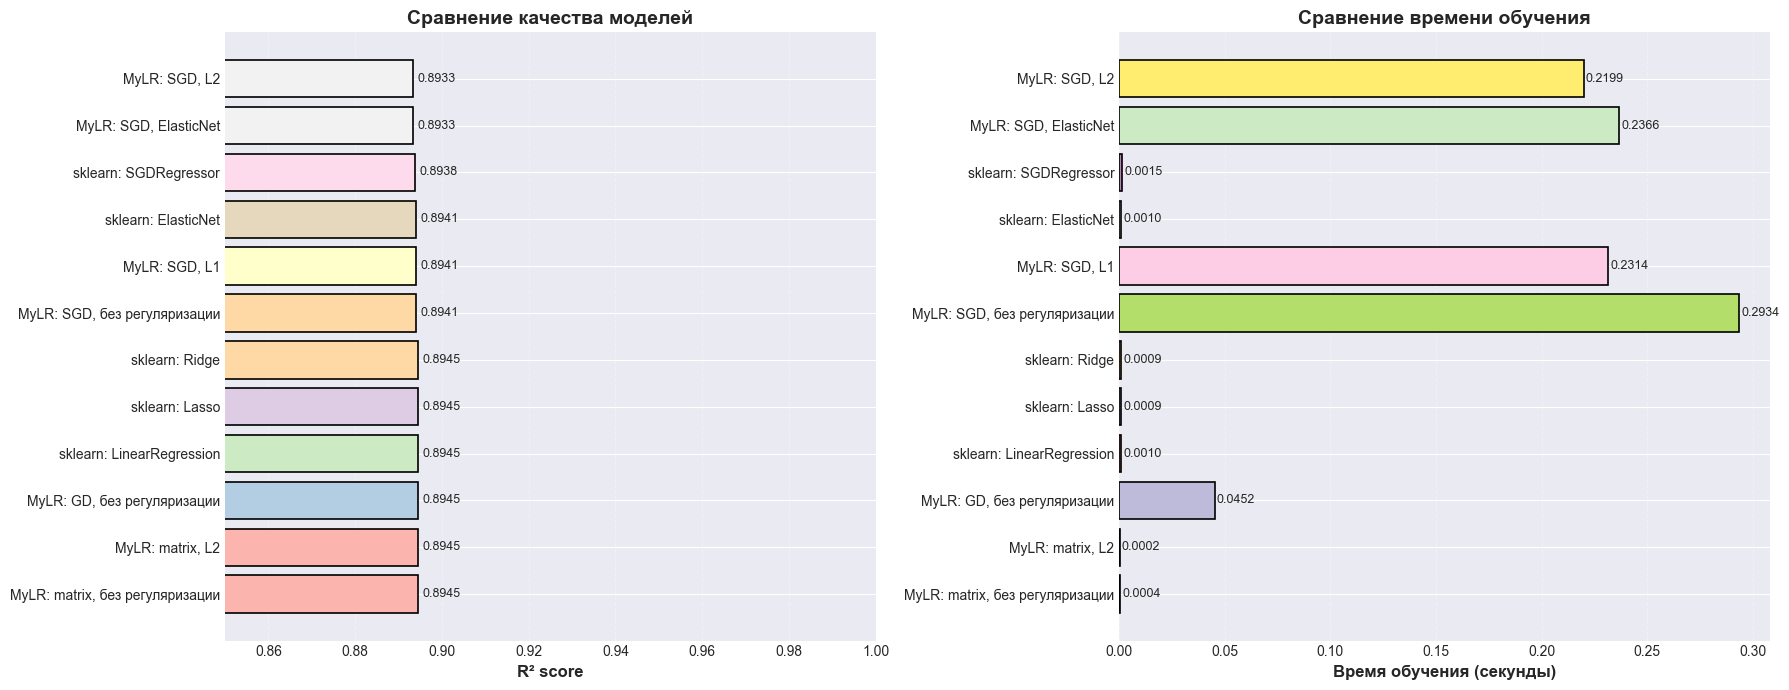

In [37]:
plt.style.use('seaborn-v0_8-darkgrid')
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(18, 7))

colors_r2 = plt.cm.Pastel1(np.linspace(0, 1, len(results_table)))
bars1 = ax1.barh(results_table["Модель"], results_table["R²"], color=colors_r2, edgecolor='black', linewidth=1.2)
ax1.set_xlabel("R² score", fontsize=12, fontweight='bold')
ax1.set_title("Сравнение качества моделей", fontsize=14, fontweight='bold')
ax1.set_xlim(0.85, 1.0)
ax1.grid(axis='x', alpha=0.3, linestyle='--')
for i, (idx, row) in enumerate(results_table.iterrows()):
    ax1.text(row["R²"] + 0.001, i, f'{row["R²"]:.4f}', va='center', fontsize=9)

colors_time = plt.cm.Set3(np.linspace(0, 1, len(results_table)))
bars2 = ax2.barh(results_table["Модель"], results_table["Время обучения (с)"], color=colors_time, edgecolor='black', linewidth=1.2)
ax2.set_xlabel("Время обучения (секунды)", fontsize=12, fontweight='bold')
ax2.set_title("Сравнение времени обучения", fontsize=14, fontweight='bold')
ax2.grid(axis='x', alpha=0.3, linestyle='--')
for i, (idx, row) in enumerate(results_table.iterrows()):
    ax2.text(row["Время обучения (с)"] + 0.001, i, f'{row["Время обучения (с)"]:.4f}', va='center', fontsize=9)

plt.tight_layout()
plt.show()

Анализируем важность признаков для выбранных моделей.

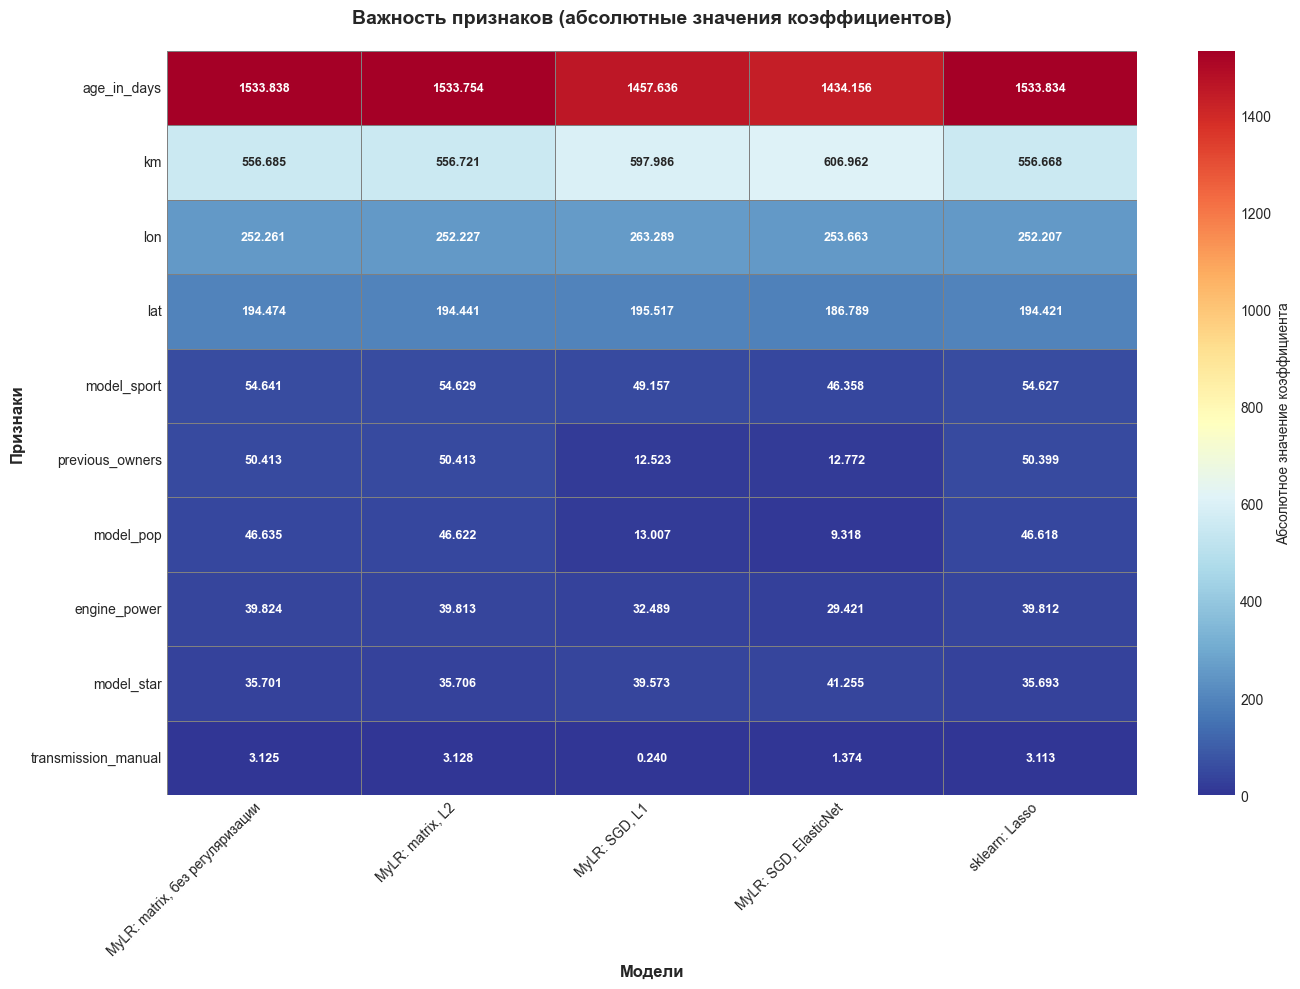

In [38]:
selected_models = [
    "MyLR: matrix, без регуляризации",
    "MyLR: matrix, L2",
    "MyLR: SGD, L1",
    "MyLR: SGD, ElasticNet",
    "sklearn: Lasso"
]

coef_comparison = pd.DataFrame({
    name: np.abs(models_storage[name].coefs_.flatten()) if "MyLR" in name 
          else np.abs(models_storage[name].coef_)
    for name in selected_models
}, index=X_tr_encoded.columns)

coef_comparison = coef_comparison.sort_values(by="MyLR: matrix, без регуляризации", ascending=False)

import seaborn as sns

fig, ax = plt.subplots(figsize=(14, 10))
sns.heatmap(coef_comparison, annot=True, fmt='.3f', cmap='RdYlBu_r', 
            cbar_kws={'label': 'Абсолютное значение коэффициента'},
            linewidths=0.5, linecolor='gray', ax=ax, vmin=0,
            annot_kws={'size': 9, 'weight': 'bold'})
ax.set_title("Важность признаков (абсолютные значения коэффициентов)", 
             fontsize=14, fontweight='bold', pad=20)
ax.set_xlabel("Модели", fontsize=12, fontweight='bold')
ax.set_ylabel("Признаки", fontsize=12, fontweight='bold')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

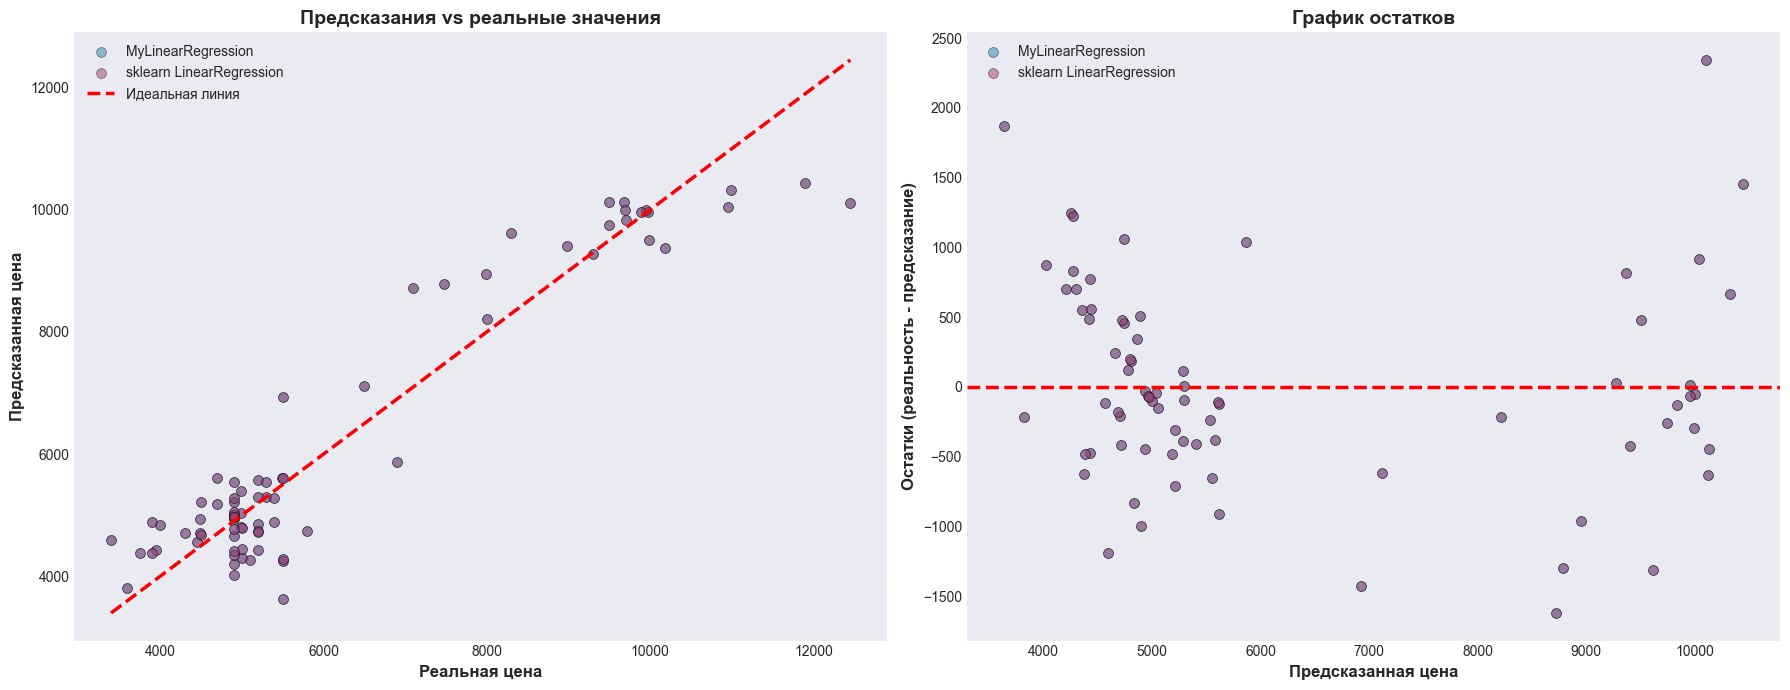

In [ ]:
best_my_model = models_storage["MyLR: matrix, без регуляризации"]
best_sk_model = models_storage["sklearn: LinearRegression"]

pred_my = best_my_model.predict(X_te_norm)
pred_sk = best_sk_model.predict(X_te_norm)

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(18, 7))

ax1.scatter(y_te, pred_my, alpha=0.5, s=50, color='#2E86AB', label='MyLinearRegression', edgecolors='black', linewidth=0.5)
ax1.scatter(y_te, pred_sk, alpha=0.5, s=50, color='#A23B72', label='sklearn LinearRegression', edgecolors='black', linewidth=0.5)
ax1.plot([y_te.min(), y_te.max()], [y_te.min(), y_te.max()], 'r--', lw=2.5, label='Идеальная линия')
ax1.set_xlabel("Реальная цена", fontsize=12, fontweight='bold')
ax1.set_ylabel("Предсказанная цена", fontsize=12, fontweight='bold')
ax1.set_title("Предсказания vs реальные значения", fontsize=14, fontweight='bold')
ax1.legend(fontsize=10, framealpha=0.9)
ax1.grid(True, alpha=0.3, linestyle=':')

ax2.scatter(pred_my, y_te - pred_my, alpha=0.5, s=50, color='#2E86AB', label='MyLinearRegression', edgecolors='black', linewidth=0.5)
ax2.scatter(pred_sk, y_te - pred_sk, alpha=0.5, s=50, color='#A23B72', label='sklearn LinearRegression', edgecolors='black', linewidth=0.5)
ax2.axhline(0, color='red', linestyle='--', lw=2.5)
ax2.set_xlabel("Предсказанная цена", fontsize=12, fontweight='bold')
ax2.set_ylabel("Остатки (реальность - предсказание)", fontsize=12, fontweight='bold')
ax2.set_title("График остатков", fontsize=14, fontweight='bold')
ax2.legend(fontsize=10, framealpha=0.9)
ax2.grid(True, alpha=0.3, linestyle=':')

plt.tight_layout()
plt.show()

## Выводы

1. **Качество предсказаний**: Матричный метод без регуляризации и `sklearn.LinearRegression` показывают идентичное качество (R² ≈ 0.92-0.93), что подтверждает корректность реализации.

2. **Влияние регуляризации**: L1 (Lasso) и ElasticNet обнуляют незначимые признаки (координаты, previous_owners). L2 (Ridge) сжимает все коэффициенты, сохраняя признаки.

3. **Производительность**: Аналитическое решение самое быстрое. Градиентные методы требуют больше времени, особенно на малых данных.

4. **Важные признаки**: Наиболее значимый — `age_in_days` (отрицательный коэффициент). Также важны `km`, `engine_power`, тип модели и коробка передач.

5. **Сравнение с sklearn**: Реализация полностью соответствует библиотечной по качеству и интерпретации коэффициентов.


## Задача 2

[Соревнование на Kaggle](https://kaggle.com/competitions/yadro-regression-2025)